In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

data = pd.read_csv("../../../datasets/plant_health_biosensor_dataset.csv")
data.sample(5)

feature_columns = [
    'Soil_Moisture',
    'light_absorption_ratio',
    'Ambient_Temperature'
]

target_column = 'Plant_Health_Status'

required_columns = feature_columns + [target_column]

missing_columns = [col for col in required_columns if col not in data.columns]

if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {missing_columns}")

print("Dataset shape:", data.shape)
print("\nColumn names:")
print(data.columns.tolist())

print("\nData types:")
print(data[required_columns].dtypes)

print("\nMissing values per required column:")
print(data[required_columns].isnull().sum())

print("\nDuplicate rows:", data.duplicated().sum())

Dataset shape: (1253, 9)

Column names:
['fluorescence_intensity', 'colorimetric_index', 'spr_signal_strength', 'Ambient_Temperature', 'chlorophyll_content', 'Soil_Moisture', 'light_absorption_ratio', 'volatile_organic_compounds', 'Plant_Health_Status']

Data types:
Soil_Moisture             float64
light_absorption_ratio    float64
Ambient_Temperature       float64
Plant_Health_Status         int64
dtype: object

Missing values per required column:
Soil_Moisture             0
light_absorption_ratio    0
Ambient_Temperature       0
Plant_Health_Status       0
dtype: int64

Duplicate rows: 0


In [3]:
dataset = data[required_columns].copy()
dataset = dataset.dropna()

print("\nShape after dropping missing values:", dataset.shape)

dataset.sample(5)


Shape after dropping missing values: (1253, 4)


,Soil_Moisture,light_absorption_ratio,Ambient_Temperature,Plant_Health_Status
909,36.873056,0.654710,20.719151,3
250,26.481448,0.734691,28.166634,3
1149,41.443953,0.665663,26.339218,3
953,24.427338,0.776878,27.048181,3
244,37.123139,0.648702,27.363152,1



Target class distribution:
Plant_Health_Status
3    811
1    285
0    114
2     43
Name: count, dtype: int64


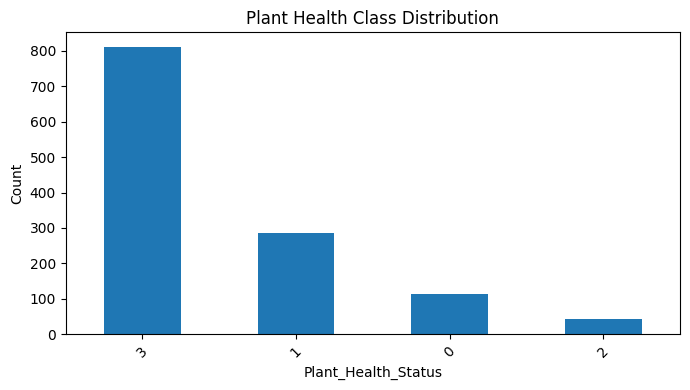

In [4]:
print("\nTarget class distribution:")
print(dataset[target_column].value_counts())

dataset[target_column].value_counts().plot(kind='bar', figsize=(7, 4))
plt.title("Plant Health Class Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
x = dataset[feature_columns]
y = dataset[target_column]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6294820717131474


In [6]:
print("Train set report:")
train_predictions = model.predict(x_train)
print(classification_report(y_train, train_predictions))

print("Test set report:")
test_predictions = model.predict(x_test)
print(classification_report(y_test, test_predictions))

Train set report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        91
           1       1.00      1.00      1.00       228
           2       1.00      1.00      1.00        34
           3       1.00      1.00      1.00       649

    accuracy                           1.00      1002
   macro avg       1.00      1.00      1.00      1002
weighted avg       1.00      1.00      1.00      1002

Test set report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        23
           1       0.37      0.12      0.18        57
           2       0.00      0.00      0.00         9
           3       0.66      0.93      0.77       162

    accuracy                           0.63       251
   macro avg       0.26      0.26      0.24       251
weighted avg       0.51      0.63      0.54       251



c:\Users\casey\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\casey\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\casey\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

<Figure size 600x600 with 0 Axes>

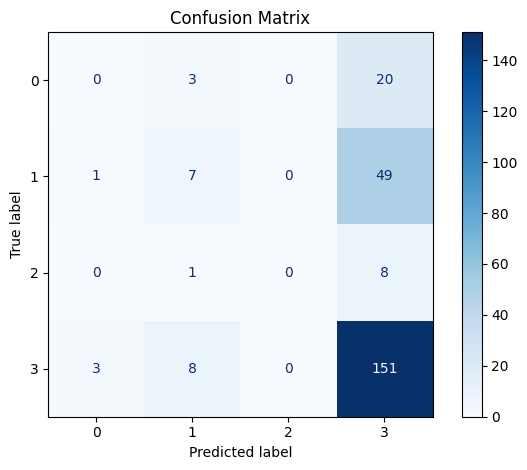

In [7]:
class_labels = sorted(y.unique())

cm = confusion_matrix(y_test, test_predictions, labels=class_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

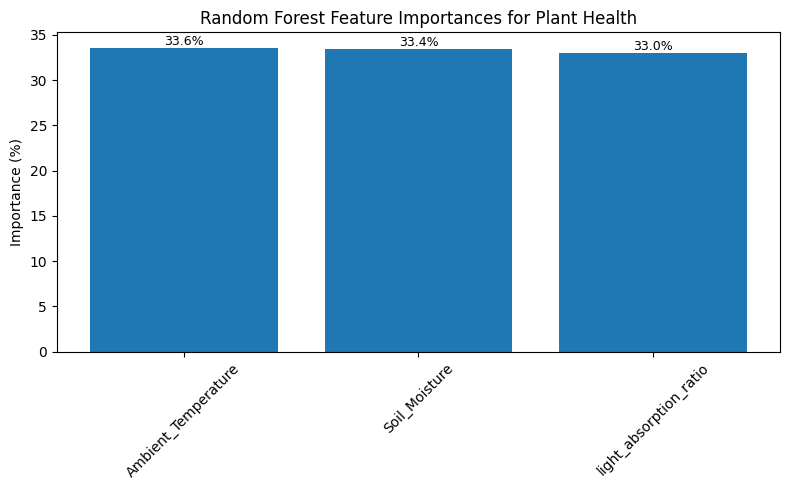

In [8]:
importances = model.feature_importances_
feature_names = x.columns
importances_pct = importances * 100

indices = np.argsort(importances_pct)[::-1]

plt.figure(figsize=(8, 5))
bars = plt.bar(range(len(importances_pct)), importances_pct[indices])

plt.xticks(
    range(len(importances_pct)),
    feature_names[indices],
    rotation=45
)

plt.ylabel("Importance (%)")
plt.title("Random Forest Feature Importances for Plant Health")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [9]:
print("Dataset Validation Summary")
print("--------------------------")
print(f"Rows used: {len(dataset)}")
print(f"Features used: {feature_columns}")
print(f"Target classes: {sorted(y.unique().tolist())}")
print(f"Missing values removed: {data[required_columns].isnull().any(axis=1).sum()}")
print(f"Duplicate rows in original data: {data.duplicated().sum()}")
print(f"Test accuracy: {accuracy_score(y_test, test_predictions):.4f}")

Dataset Validation Summary
--------------------------
Rows used: 1253
Features used: ['Soil_Moisture', 'light_absorption_ratio', 'Ambient_Temperature']
Target classes: [0, 1, 2, 3]
Missing values removed: 0
Duplicate rows in original data: 0
Test accuracy: 0.6295


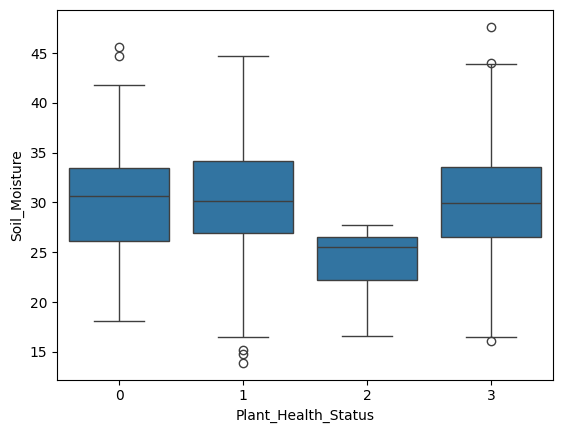

In [10]:
import seaborn as sns

sns.boxplot(x='Plant_Health_Status', y='Soil_Moisture', data=dataset)
plt.show()

 97%|=================== | 974/1004 [00:11<00:00]       

(251, 3, 4)


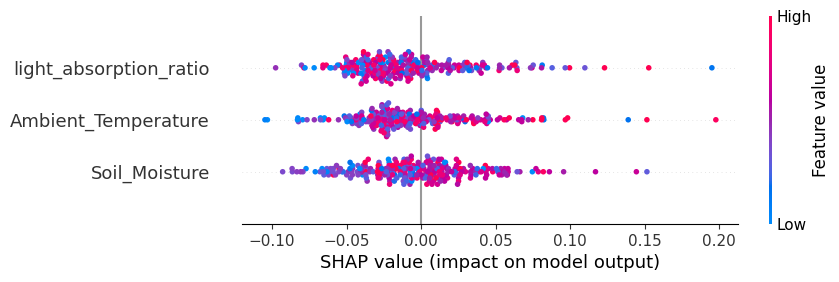

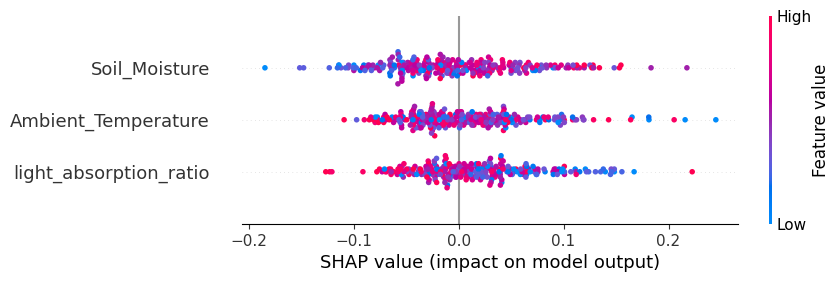

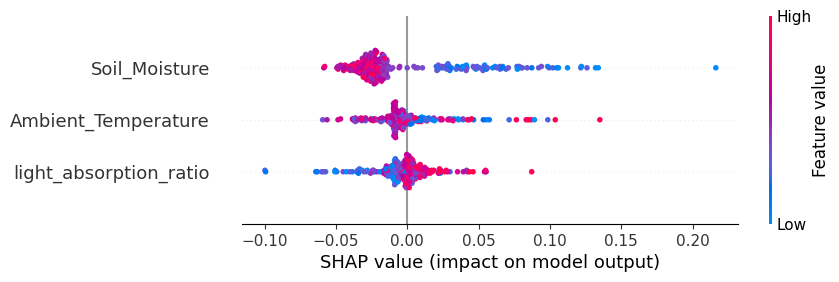

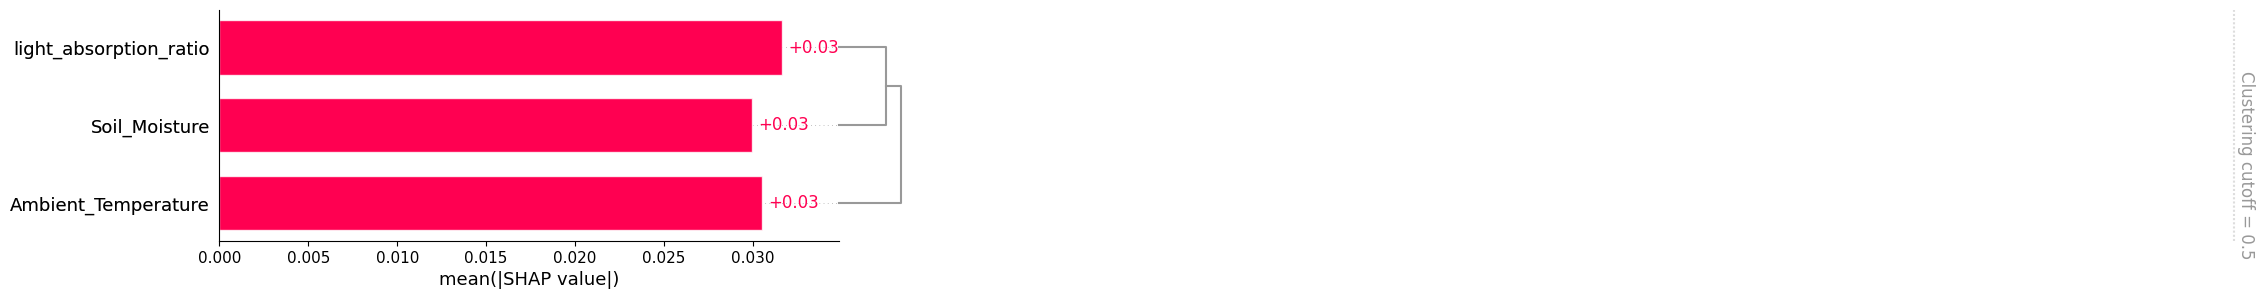

In [14]:
import shap

explainer = shap.Explainer(model, x_train)
shap_values = explainer(x_test)

print(shap_values.shape)

shap.plots.beeswarm(shap_values[..., 0])

shap.plots.beeswarm(shap_values[..., 1])
shap.plots.beeswarm(shap_values[..., 2])

clustering = shap.utils.hclust(x)
shap.plots.bar(shap_values[..., 0], clustering=clustering)

In [16]:
global_importance = np.abs(shap_values.values).mean(axis=(0, 2))

importance_df = pd.DataFrame({
    "feature": x_test.columns,
    "mean_abs_shap": global_importance
}).sort_values("mean_abs_shap", ascending=False)

print("Mean SHAP:", np.abs(shap_values.values).mean())
print("Max SHAP:", np.abs(shap_values.values).max())

print(importance_df)

Mean SHAP: 0.03799792995581937
Max SHAP: 0.24509999418864026
                  feature  mean_abs_shap
0           Soil_Moisture       0.044033
2     Ambient_Temperature       0.035367
1  light_absorption_ratio       0.034595
